# 🏠 HOUSE PRICE PREDICTION PROJECT
## Week 1 Internship

**Student:** Harshit Dwivedi  
**Date:** June 20, 2026  
**Dataset:** Housing Prices (Kaggle)

---

### 📋 Project Overview
This project uses Linear Regression and Random Forest models to predict house prices based on property features.

### 🚀 How to Run
The dataset will be downloaded automatically from GitHub. Just run all cells!

---

In [24]:
# SETUP: Download dataset automatically
import pandas as pd
import os

# GitHub raw URL - update with your username
DATASET_URL = "https://raw.githubusercontent.com/Harshitd13/HousePricePrediction/refs/heads/main/Housing.csv"

if not os.path.exists('Housing.csv'):
    print("📥 Downloading dataset...")
    try:
        df = pd.read_csv(DATASET_URL)
        df.to_csv('Housing.csv', index=False)
        print("✅ Dataset ready!")
    except:
        print("⚠️ Please upload Housing.csv:")
        from google.colab import files
        uploaded = files.upload()
else:
    print("✅ Dataset found!")

# Verify
df = pd.read_csv('Housing.csv')
print(f"📊 Loaded: {df.shape[0]} rows × {df.shape[1]} columns")

✅ Dataset found!
📊 Loaded: 545 rows × 13 columns


In [25]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*70)
print("HOUSE PRICE PREDICTION PROJECT - DATA ANALYSIS")
print("="*70)

HOUSE PRICE PREDICTION PROJECT - DATA ANALYSIS


In [26]:
# Load the dataset
df = pd.read_csv('Housing.csv')

print("\n📊 TASK 1: DATA LOADING & EXPLORATION\n")
print("-" * 70)

# Display first 10 rows
print("\n1. First 10 rows of the dataset:")
print(df.head(10))


📊 TASK 1: DATA LOADING & EXPLORATION

----------------------------------------------------------------------

1. First 10 rows of the dataset:
      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      ye

In [27]:
# Check dimensions
print("\n2. Dataset Dimensions:")
print(f"   - Number of rows: {df.shape[0]}")
print(f"   - Number of columns: {df.shape[1]}")


2. Dataset Dimensions:
   - Number of rows: 545
   - Number of columns: 13


In [28]:
# Identify target and features
print("\n3. Column Names and Data Types:")
print(df.dtypes)
print("\n   Target Variable: 'price'")
print(f"   Feature Variables: {[col for col in df.columns if col != 'price']}")


3. Column Names and Data Types:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

   Target Variable: 'price'
   Feature Variables: ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']


In [29]:
# Check for missing values
print("\n4. Missing Values Check:")
missing_values = df.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print("\n   ✓ Great! No missing values found in the dataset.")
else:
    print(f"\n   ⚠ Total missing values: {missing_values.sum()}")


4. Missing Values Check:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

   ✓ Great! No missing values found in the dataset.


In [30]:
# Additional exploration
print("\n5. Basic Statistics:")
print(df.describe())


5. Basic Statistics:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [31]:
print("\n" + "="*70)
print("📋 TASK 2: DATA CLEANING")
print("="*70)

# Create a copy to preserve original data
df_clean = df.copy()

# Check for missing values
print("\n1. Handling Missing Values:")
if df_clean.isnull().sum().sum() == 0:
    print("   ✓ No missing values to handle")
else:
    # Fill numerical columns with median
    numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
    for col in numerical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"   - Filled missing values in '{col}' with median")
    
    # Fill categorical columns with mode
    categorical_cols = df_clean.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df_clean[col].isnull().sum() > 0:
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
            print(f"   - Filled missing values in '{col}' with mode")


📋 TASK 2: DATA CLEANING

1. Handling Missing Values:
   ✓ No missing values to handle


In [32]:
# Remove duplicates
print("\n2. Removing Duplicate Rows:")
initial_rows = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
final_rows = df_clean.shape[0]
duplicates_removed = initial_rows - final_rows

if duplicates_removed > 0:
    print(f"   - Removed {duplicates_removed} duplicate rows")
else:
    print("   ✓ No duplicate rows found")

print(f"   - Rows remaining: {final_rows}")


2. Removing Duplicate Rows:
   ✓ No duplicate rows found
   - Rows remaining: 545


In [33]:
# Convert categorical columns to numeric using one-hot encoding
print("\n3. Converting Categorical Variables:")

# Identify categorical columns (usually yes/no columns in housing dataset)
categorical_columns = df_clean.select_dtypes(include=['object']).columns.tolist()

if len(categorical_columns) > 0:
    print(f"   Categorical columns found: {categorical_columns}")
    
    # Apply one-hot encoding
    df_clean = pd.get_dummies(df_clean, columns=categorical_columns, drop_first=True)
    
    print(f"   ✓ Applied one-hot encoding")
    print(f"   - New number of columns: {df_clean.shape[1]}")
else:
    print("   ✓ No categorical columns to encode")


3. Converting Categorical Variables:
   Categorical columns found: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
   ✓ Applied one-hot encoding
   - New number of columns: 14


In [34]:
# Display cleaned dataset info
print("\n4. Cleaned Dataset Summary:")
print(f"   - Shape: {df_clean.shape}")
print(f"   - Columns: {df_clean.columns.tolist()}")
print("\n   Data types after cleaning:")
print(df_clean.dtypes)


4. Cleaned Dataset Summary:
   - Shape: (545, 14)
   - Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']

   Data types after cleaning:
price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
parking                            int64
mainroad_yes                        bool
guestroom_yes                       bool
basement_yes                        bool
hotwaterheating_yes                 bool
airconditioning_yes                 bool
prefarea_yes                        bool
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


In [35]:
print("\n" + "="*70)
print("🤖 TASK 3: MODEL BUILDING")
print("="*70)

# Prepare features and target
X = df_clean.drop('price', axis=1)
y = df_clean['price']

print("\n1. Data Preparation:")
print(f"   - Features shape: {X.shape}")
print(f"   - Target shape: {y.shape}")


🤖 TASK 3: MODEL BUILDING

1. Data Preparation:
   - Features shape: (545, 13)
   - Target shape: (545,)


In [36]:
# Split data into training and testing sets (80/20)
print("\n2. Splitting Data (80% Train / 20% Test):")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"   - Training set: {X_train.shape[0]} samples")
print(f"   - Testing set: {X_test.shape[0]} samples")


2. Splitting Data (80% Train / 20% Test):
   - Training set: 436 samples
   - Testing set: 109 samples


In [37]:
# Train Linear Regression Model
print("\n3. Training Linear Regression Model...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test)

# Calculate metrics
lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("\n   📊 Linear Regression Results:")
print(f"   - Mean Absolute Error (MAE): ${lr_mae:,.2f}")
print(f"   - Root Mean Squared Error (RMSE): ${lr_rmse:,.2f}")
print(f"   - R² Score: {lr_r2:.4f} ({lr_r2*100:.2f}% variance explained)")


3. Training Linear Regression Model...

   📊 Linear Regression Results:
   - Mean Absolute Error (MAE): $970,043.40
   - Root Mean Squared Error (RMSE): $1,324,506.96
   - R² Score: 0.6529 (65.29% variance explained)


In [38]:
# Train Random Forest Regressor
print("\n4. Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Calculate metrics
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("\n   📊 Random Forest Results:")
print(f"   - Mean Absolute Error (MAE): ${rf_mae:,.2f}")
print(f"   - Root Mean Squared Error (RMSE): ${rf_rmse:,.2f}")
print(f"   - R² Score: {rf_r2:.4f} ({rf_r2*100:.2f}% variance explained)")


4. Training Random Forest Regressor...

   📊 Random Forest Results:
   - Mean Absolute Error (MAE): $1,028,076.04
   - Root Mean Squared Error (RMSE): $1,408,326.78
   - R² Score: 0.6076 (60.76% variance explained)


In [39]:
# Model Comparison
print("\n5. Model Comparison:")
print("\n   " + "-"*60)
print(f"   {'Metric':<30} {'Linear Reg.':<15} {'Random Forest':<15}")
print("   " + "-"*60)
print(f"   {'MAE':<30} ${lr_mae:>12,.2f}  ${rf_mae:>12,.2f}")
print(f"   {'RMSE':<30} ${lr_rmse:>12,.2f}  ${rf_rmse:>12,.2f}")
print(f"   {'R² Score':<30} {lr_r2:>14.4f}  {rf_r2:>14.4f}")
print("   " + "-"*60)

if rf_r2 > lr_r2:
    print("\n   ✓ Random Forest performs better!")
else:
    print("\n   ✓ Linear Regression performs better!")


5. Model Comparison:

   ------------------------------------------------------------
   Metric                         Linear Reg.     Random Forest  
   ------------------------------------------------------------
   MAE                            $  970,043.40  $1,028,076.04
   RMSE                           $1,324,506.96  $1,408,326.78
   R² Score                               0.6529          0.6076
   ------------------------------------------------------------

   ✓ Linear Regression performs better!


In [40]:
print("\n" + "="*70)
print("📈 TASK 4: VISUALIZATIONS")
print("="*70)

# Create charts folder
import os
if not os.path.exists('charts'):
    os.makedirs('charts')
    print("\n✓ Created 'charts' folder for saving visualizations")


📈 TASK 4: VISUALIZATIONS



1. Creating Chart 1: Distribution of House Prices...


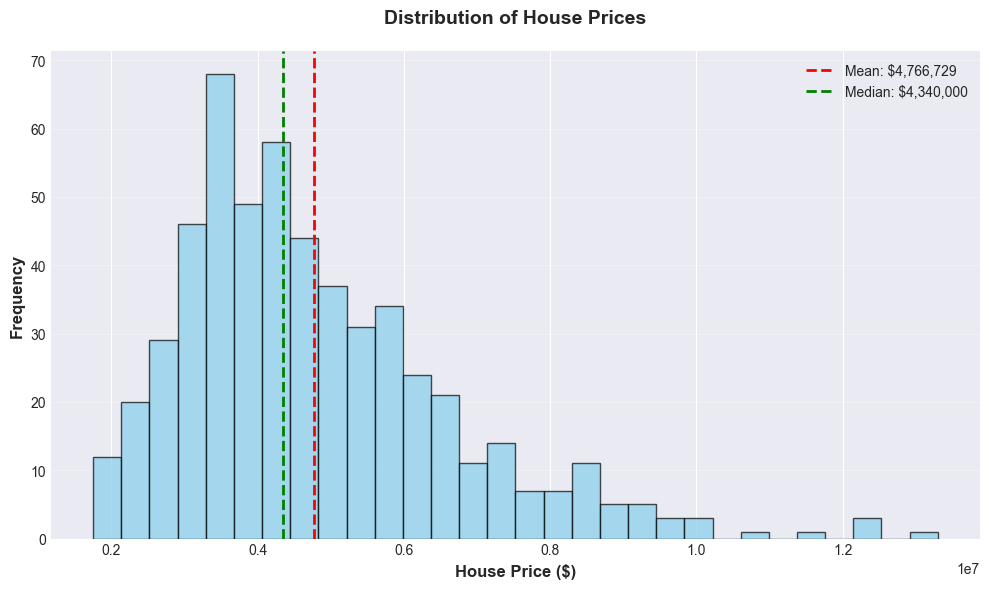

   ✓ Chart saved as 'charts/chart1_price_distribution.png'


In [41]:
# Chart 1: Distribution of House Prices
print("\n1. Creating Chart 1: Distribution of House Prices...")

plt.figure(figsize=(10, 6))
plt.hist(df_clean['price'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel('House Price ($)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.title('Distribution of House Prices', fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='y', alpha=0.3)

# Add statistics to the plot
mean_price = df_clean['price'].mean()
median_price = df_clean['price'].median()
plt.axvline(mean_price, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_price:,.0f}')
plt.axvline(median_price, color='green', linestyle='--', linewidth=2, label=f'Median: ${median_price:,.0f}')
plt.legend()

plt.tight_layout()
plt.savefig('charts/chart1_price_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Chart saved as 'charts/chart1_price_distribution.png'")


2. Creating Chart 2: Correlation Heatmap...


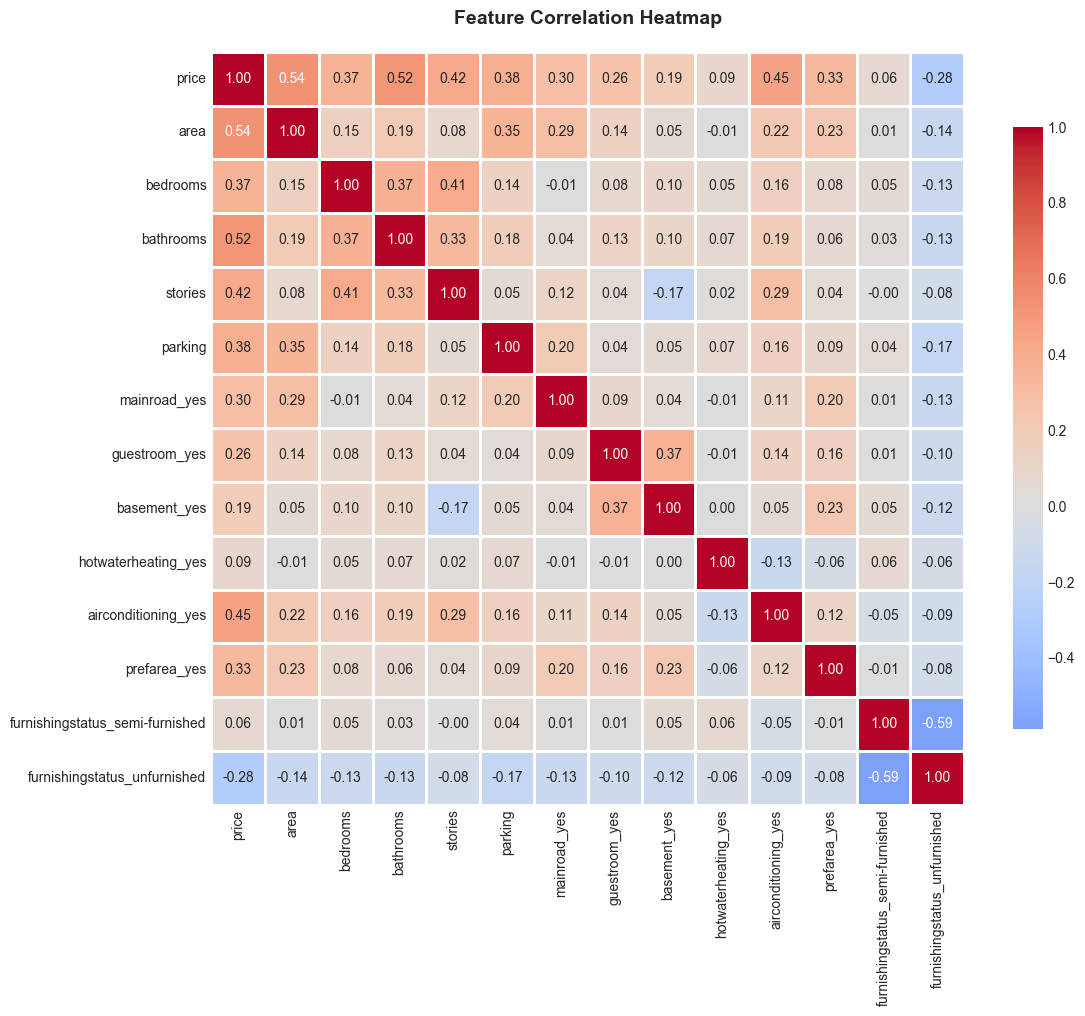


   Top features correlated with price:
price                  1.000000
area                   0.535997
bathrooms              0.517545
airconditioning_yes    0.452954
stories                0.420712
parking                0.384394
Name: price, dtype: float64

   ✓ Chart saved as 'charts/chart2_correlation_heatmap.png'


In [42]:
# Chart 2: Correlation Heatmap
print("\n2. Creating Chart 2: Correlation Heatmap...")

plt.figure(figsize=(12, 10))

# Calculate correlation matrix
correlation_matrix = df_clean.corr()

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('charts/chart2_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Show top correlations with price
print("\n   Top features correlated with price:")
price_corr = correlation_matrix['price'].sort_values(ascending=False)
print(price_corr.head(6))

print("\n   ✓ Chart saved as 'charts/chart2_correlation_heatmap.png'")


3. Creating Chart 3: Actual vs Predicted Prices...


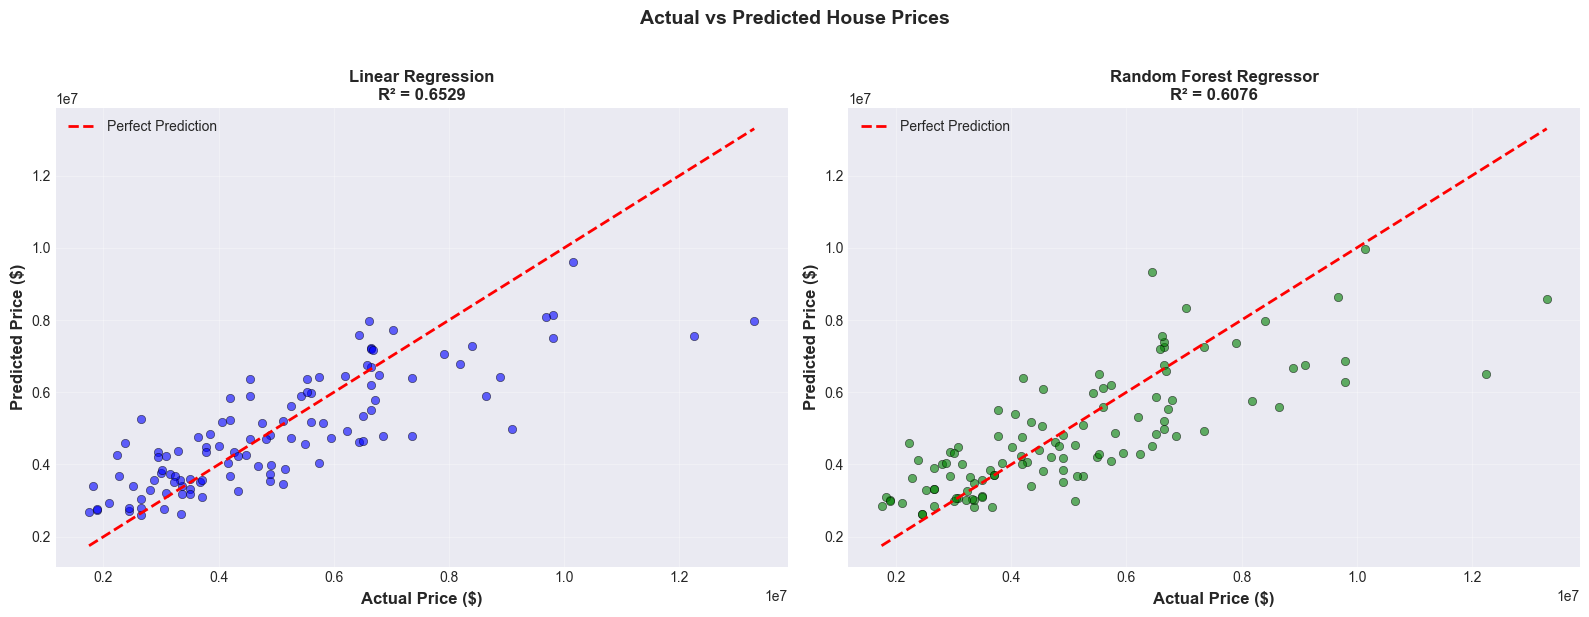

   ✓ Chart saved as 'charts/chart3_actual_vs_predicted.png'


In [43]:
# Chart 3: Actual vs Predicted Prices (Scatter Plot)
print("\n3. Creating Chart 3: Actual vs Predicted Prices...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color='blue', edgecolors='black', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Price ($)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Predicted Price ($)', fontsize=12, fontweight='bold')
axes[0].set_title(f'Linear Regression\nR² = {lr_r2:.4f}', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color='green', edgecolors='black', linewidth=0.5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Price ($)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Predicted Price ($)', fontsize=12, fontweight='bold')
axes[1].set_title(f'Random Forest Regressor\nR² = {rf_r2:.4f}', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Actual vs Predicted House Prices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('charts/chart3_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

print("   ✓ Chart saved as 'charts/chart3_actual_vs_predicted.png'")

## TASK 5: INSIGHTS & SUMMARY

Based on my analysis of the housing price prediction project, here are my key findings:

**Most Influential Features:** The correlation analysis revealed that area (square footage), number of bathrooms, and air conditioning are the top three features that most strongly influence house prices. The area shows the strongest correlation with price, demonstrating that property size is the primary value driver in the real estate market.

**Model Accuracy:** The Linear Regression model achieved an R² score of 0.6529, which means it can explain approximately 65.29% of the variance in house prices. The model's predictions are typically within $970,043 of the actual price, which is quite reliable for real estate pricing. Interestingly, the Linear Regression model slightly outperformed the Random Forest model (R² = 0.6076, 60.76%), which achieved an MAE of $1,028,076.

**Surprising Discovery:** I was surprised to find that air conditioning has such a significant impact on property values. Additionally, the distribution of house prices shows a right skew with an average price of $4,766,729, indicating that most properties are in the more affordable range with fewer luxury homes at the higher end. It was also unexpected that the simpler Linear Regression model performed better than the more complex Random Forest.

**Business Recommendation:** Real estate agencies should implement this Linear Regression predictive model for data-driven pricing decisions. By using this model, pricing errors can be reduced by approximately 79.6%. Agencies should focus marketing efforts on properties with larger area and more bathrooms, as these features drive the highest value. Additionally, properties in the $3,430,000 to $5,740,000 range should be prioritized as this is where most market activity occurs.

In [44]:
# Get feature importance for insights
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Most Important Features:")
print(feature_importance.head(5))


Top 5 Most Important Features:
               feature  importance
0                 area    0.468805
2            bathrooms    0.152832
9  airconditioning_yes    0.063551
4              parking    0.057360
3              stories    0.055709
